# LeWorldModel (LeWM)

**Goal:** run a *real forward inference* with the pretrained **LeWM PushT** checkpoint from the official project, without training a model and without downloading the full PushT dataset.

Repository: https://github.com/lucas-maes/le-wm  
Pretrained checkpoint: https://huggingface.co/quentinll/lewm-pusht  
Project page: https://le-wm.github.io/


### What we will actually demonstrate

1. Load the official LeWM architecture and pretrained PushT weights.
2. Encode an image history into latent states.
3. Encode candidate actions.
4. Predict future latent states autoregressively.
5. Encode a goal image.
6. Score candidate futures by their latent distance to the goal.

This is the central inference loop behind latent-space planning with a learned world model.

## 1. Setup

The official `le-wm` repository contains the LeWM/JEPA implementation.  
We clone it directly and install only the dependencies needed for inference.

The notebook deliberately avoids downloading the full PushT training dataset because it is not necessary for demonstrating the model's forward pass.

In [1]:

%%capture
%pip install -q "stable-pretraining==0.1.8" "transformers==4.57.6" \
    "huggingface_hub<1.0" einops scikit-learn

!rm -rf /content/le-wm
!git clone -q --depth 1 https://github.com/lucas-maes/le-wm.git /content/le-wm

In [2]:
import sys
import json
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import transformers
import stable_pretraining as spt

from PIL import Image, ImageSequence
from huggingface_hub import snapshot_download
from sklearn.decomposition import PCA
from torchvision.transforms import v2 as T

sys.path.insert(0, "/content/le-wm")

print("transformers:", transformers.__version__)
print("stable-pretraining:", getattr(spt, "__version__", "0.1.8"))

assert transformers.__version__.startswith("4."), (
    "This checkpoint requires Transformers 4.x. "
    "Restart the Colab runtime and run the notebook from the first cell."
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

transformers: 4.57.6
stable-pretraining: 0.1.8
Device: cuda
GPU: Tesla T4


## 2. What does inference mean in LeWM?

Let

$
x_t = \text{image observation at time }t,
\qquad
a_t = \text{action}.
$

LeWM first converts an image into a compact representation:

$
z_t = E_\theta(x_t).
$

The action is also embedded:

$
u_t = A_\psi(a_t).
$

Given a short history of latent states and actions, the predictor estimates the next latent:

$
\hat z_{t+1}
=
P_\phi(z_{t-H+1:t}, u_{t-H+1:t}).
$

For several future steps, this becomes **autoregressive**:

$
\hat z_{t+1}
\rightarrow
\hat z_{t+2}
\rightarrow
\cdots
\rightarrow
\hat z_{t+K}.
$

For goal-conditioned planning, the goal image is encoded once:

$
z_{\text{goal}} = E_\theta(x_{\text{goal}})
$

and a candidate action sequence can be scored by

$
J =
\left\|
\hat z_{t+K}
-
z_{\text{goal}}
\right\|_2^2.
$

**Important:** no future RGB frame needs to be decoded. The model predicts directly in representation space.

## 3. Load the official pretrained PushT checkpoint

For reproducibility, this notebook pins a known revision of the official Hugging Face checkpoint.

The PushT configuration used here has:

- image size: **224 × 224**
- latent dimension: **192**
- context/history length: **3 frames**
- action input dimension: **10**

For PushT, the 10-D action feature corresponds to a short block of 2-D actions flattened together.

In [3]:
# Download checkpoint + build LeWM with the checkpoint-compatible ViT
from jepa import JEPA
from module import ARPredictor, Embedder, MLP

REPO_ID = "quentinll/lewm-pusht"

# Use the official Hugging Face mirror.
model_dir = Path(
    snapshot_download(
        repo_id=REPO_ID,
        allow_patterns=["config.json", "weights.pt"],
    )
)

with open(model_dir / "config.json", "r") as f:
    cfg = json.load(f)

def without_target(d):
    """Remove Hydra metadata such as `_target_` before calling constructors."""
    return {k: v for k, v in d.items() if not str(k).startswith("_")}

# This is the same ViT construction used by the official LeWM loading recipe.
# Transformers MUST remain on 4.x so that its parameter names match weights.pt.
encoder = spt.backbone.utils.vit_hf(
    cfg["encoder"]["size"],
    patch_size=cfg["encoder"]["patch_size"],
    image_size=cfg["encoder"]["image_size"],
    pretrained=False,
    use_mask_token=False,
)

predictor = ARPredictor(**without_target(cfg["predictor"]))
action_encoder = Embedder(**without_target(cfg["action_encoder"]))

projector = MLP(
    input_dim=cfg["projector"]["input_dim"],
    output_dim=cfg["projector"]["output_dim"],
    hidden_dim=cfg["projector"]["hidden_dim"],
    norm_fn=torch.nn.BatchNorm1d,
)

pred_proj = MLP(
    input_dim=cfg["pred_proj"]["input_dim"],
    output_dim=cfg["pred_proj"]["output_dim"],
    hidden_dim=cfg["pred_proj"]["hidden_dim"],
    norm_fn=torch.nn.BatchNorm1d,
)

model = JEPA(
    encoder=encoder,
    predictor=predictor,
    action_encoder=action_encoder,
    projector=projector,
    pred_proj=pred_proj,
)

# strict=True is intentional.
# If this succeeds, ALL checkpoint tensors matched the reconstructed model.
state_dict = torch.load(
    model_dir / "weights.pt",
    map_location="cpu",
    weights_only=False,
)

incompat = model.load_state_dict(state_dict, strict=True)

model = model.eval().requires_grad_(False).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())

print("✓ Checkpoint loaded with strict=True")
print(f"Loaded: {REPO_ID}")
print(f"Parameters: {n_params/1e6:.2f} M")
print("Latent dimension:", cfg["predictor"]["input_dim"])
print("History frames:", cfg["predictor"]["num_frames"])
print("Action dimension:", cfg["action_encoder"]["input_dim"])

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

04:24:50 | INFO  | __init__.py | TensorFlow version 2.20.0 available.
04:24:50 | INFO  | __init__.py | JAX version 0.11.1 available.
04:24:52 | INFO  | atomic_chec~| [atomic_save] installed crash-safe checkpoint plugin (write to sibling .tmp + fsync + atomic rename)
04:24:53 | INFO  | utils.py    | Created ViT-tiny from scratch with config: {'hidden_size': 192, 'num_hidden_layers': 12, 'num_attention_heads': 3, 'intermediate_size': 768, 'image_size': 224, 'patch_size': 14}
✓ Checkpoint loaded with strict=True
Loaded: quentinll/lewm-pusht
Parameters: 18.03 M
Latent dimension: 192
History frames: 3
Action dimension: 10


### What is inside the model?

The inference path is conceptually:

```text
RGB frames
   │
   ▼
visual encoder
   │
   ▼
z(t-2), z(t-1), z(t)
                    candidate actions
                         │
                         ▼
                   action encoder
                         │
                         ▼
                  autoregressive
                    predictor
                         │
                         ▼
       ẑ(t+1), ẑ(t+2), ..., ẑ(t+K)
                         │
                         ▼
                 distance to z_goal
```

The key point for the tutorial is that the predictor receives **representations + actions**, not raw future pixels.

## 4. Obtain a real PushT visual example

To keep this notebook lightweight, we use a frame from the **official LeWM PushT planning visualization** hosted on the project website.

The published GIF places the rollout view and goal view side-by-side. We extract the first frame and split the two panels.

This gives us a visually meaningful observation and goal without downloading the multi-gigabyte training dataset.

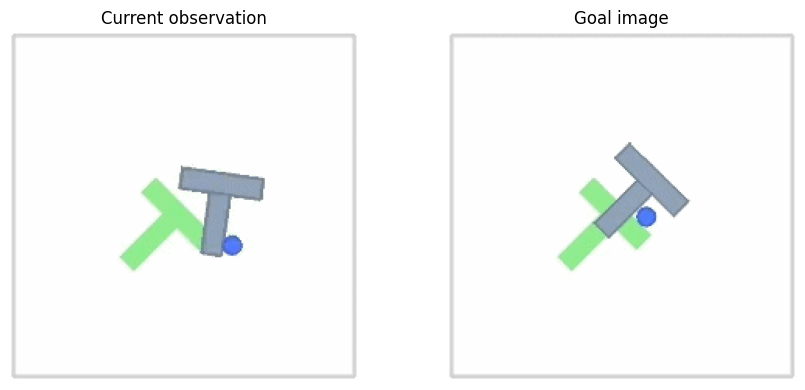

Source GIF size: (224, 448, 3)


In [4]:
# Download and inspect an official PushT example
GIF_URL = "https://le-wm.github.io/static/videos/planning/pusht/pusht_1_half.gif"
gif_path = "/content/lewm_pusht_demo.gif"

urllib.request.urlretrieve(GIF_URL, gif_path)

gif = Image.open(gif_path)
frame0 = next(ImageSequence.Iterator(gif)).convert("RGB")
frame0_np = np.array(frame0)

h, w, _ = frame0_np.shape
mid = w // 2

current_img = frame0_np[:, :mid]
goal_img = frame0_np[:, mid:]

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(current_img)
ax[0].set_title("Current observation")
ax[0].axis("off")

ax[1].imshow(goal_img)
ax[1].set_title("Goal image")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print("Source GIF size:", frame0_np.shape)

## 5. Preprocess the images and create the model context  

The pretrained visual encoder expects ImageNet-normalized images at **224 × 224**.

LeWM's PushT predictor was trained with a context of **3 frames**. For a minimal inference example, we warm-start the context by repeating the current observation:

$
[x_t, x_t, x_t].
$

This lets us demonstrate temporal inference without requiring a long recorded trajectory.

In [5]:
#@title Image preprocessing + 3-frame history
IMG_SIZE = 224
HISTORY = int(cfg["predictor"]["num_frames"])
LATENT_DIM = int(cfg["predictor"]["input_dim"])
ACTION_DIM = int(cfg["action_encoder"]["input_dim"])

image_tf = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

current_tensor = image_tf(current_img)
goal_tensor = image_tf(goal_img)

# (history, channels, height, width)
context_pixels = current_tensor.unsqueeze(0).repeat(HISTORY, 1, 1, 1)

print("Context pixels:", tuple(context_pixels.shape))
print("Goal tensor:", tuple(goal_tensor.shape))

Context pixels: (3, 3, 224, 224)
Goal tensor: (3, 224, 224)


## 6. Build a few candidate future action sequences

The official evaluation pipeline standardizes PushT actions using statistics computed from the training dataset.

To keep this notebook independent of that large dataset, we use **small candidate vectors directly in the normalized action-feature space** expected by the model.

Therefore:

- these are valid numeric inputs for demonstrating the LeWM forward pass;
- they are **not claimed to be exact raw PushT mouse/controller commands**;
- the purpose is to show how different hypothetical controls create different predicted latent futures.

Each 10-D vector represents five consecutive 2-D action slots.

In [6]:
#@title Candidate actions in normalized model space
HORIZON = 5

candidate_xy = {
    "mean / zero": (0.0, 0.0),
    "+ channel 1": (0.55, 0.0),
    "- channel 1": (-0.55, 0.0),
    "+ channel 2": (0.0, 0.55),
    "- channel 2": (0.0, -0.55),
    "diagonal +/+": (0.40, 0.40),
}

def action_block(xy, action_dim=ACTION_DIM):
    xy = torch.tensor(xy, dtype=torch.float32)
    return xy.repeat(action_dim // 2)

candidate_names = list(candidate_xy)

candidate_actions = torch.stack([
    action_block(candidate_xy[name]).unsqueeze(0).repeat(HORIZON, 1)
    for name in candidate_names
], dim=0)

# (number of candidates, future horizon, action dimension)
print("Candidate action tensor:", tuple(candidate_actions.shape))

Candidate action tensor: (6, 5, 10)


## 7. The actual LeWM inference loop  

This is the core of the notebook.

First we encode the current visual context:

$
z_{t-2:t} = E(x_{t-2:t}).
$

Then, for every candidate action sequence, we repeatedly call the predictor.

At each future step:

1. keep the most recent context window;
2. combine latent history with the corresponding action embeddings;
3. predict one next latent;
4. append it to the trajectory;
5. feed the predicted latent back into the next prediction.

That is an **autoregressive latent rollout**.

In [7]:
#@title Run the OFFICIAL LeWM autoregressive rollout
@torch.inference_mode()
def encode_pixels(pixel_sequence):
    # pixel_sequence: (T, C, H, W) -> (1, T, D)
    info = {"pixels": pixel_sequence.unsqueeze(0).to(DEVICE)}
    return model.encode(info)["emb"]

# Encode the goal once.
goal_emb = encode_pixels(goal_tensor.unsqueeze(0))[:, -1, :]  # (1, D)

# model.rollout expects:
#   pixels:          (B, S, H, C, image_h, image_w)
#   action_sequence: (B, S, T, action_dim)
#
# B = 1 batch
# S = number of candidate plans
# H = history/context frames (= 3)
S = len(candidate_names)

context_for_rollout = (
    context_pixels
    .unsqueeze(0)            # (1, H, C, h, w)
    .unsqueeze(1)            # (1, 1, H, C, h, w)
    .expand(1, S, -1, -1, -1, -1)
    .contiguous()
    .to(DEVICE)
)

# To obtain K future latent predictions, the official rollout needs
# H-1 warm-start/history actions followed by K candidate future actions.
history_actions = torch.zeros(
    S,
    HISTORY - 1,
    ACTION_DIM,
    dtype=torch.float32,
)

action_sequence = torch.cat(
    [history_actions, candidate_actions],
    dim=1,
).unsqueeze(0).to(DEVICE)  # (1, S, H-1+K, A)

rollout_info = {"pixels": context_for_rollout}

t0 = time.perf_counter()

rollout_info = model.rollout(
    rollout_info,
    action_sequence,
    history_size=HISTORY,
)

if DEVICE == "cuda":
    torch.cuda.synchronize()

elapsed = time.perf_counter() - t0

# Official output:
# (B, S, HISTORY + HORIZON, latent_dim)
predicted_emb = rollout_info["predicted_emb"]

# Remove the batch dimension for easier plotting below.
all_rollouts = predicted_emb[0]

print("Goal embedding:", tuple(goal_emb.shape))
print("Action plans:", tuple(action_sequence.shape))
print("Predicted latent trajectories:", tuple(predicted_emb.shape))
print(
    f"Official rollout time for {S} candidates: "
    f"{elapsed * 1000:.1f} ms"
)

assert all_rollouts.shape[1] == HISTORY + HORIZON
assert all_rollouts.shape[2] == LATENT_DIM

print("✓ Official model.rollout() completed successfully")

Goal embedding: (1, 192)
Action plans: (1, 6, 7, 10)
Predicted latent trajectories: (1, 6, 8, 192)
Official rollout time for 6 candidates: 202.6 ms
✓ Official model.rollout() completed successfully


### What just happened?

The RGB observation was compressed into a 192-D state representation.

For each candidate control sequence, LeWM generated a different sequence of future 192-D states.

We still have not rendered a single predicted image.

> **LeWM asks “what representation should come next if I take this action?” rather than “what should every future pixel look like?”**

## 8. Score the candidate futures against the goal

We now use the simple latent planning objective:

$
J_i
=
\left\|
\hat z^{(i)}_{t+K}
-
z_{\mathrm{goal}}
\right\|_2^2.
$

A **smaller** value means that, according to the learned representation, the candidate's predicted final state is closer to the encoded goal.

For this short tutorial, the scores demonstrate the mechanism; they are not a reproduction of the paper's full PushT controller.

,candidate,latent goal distance ↓
0,- channel 1,103.511292
1,mean / zero,190.997284
2,- channel 2,302.240234
3,+ channel 2,340.386322
4,diagonal +/+,352.022003
5,+ channel 1,354.788940


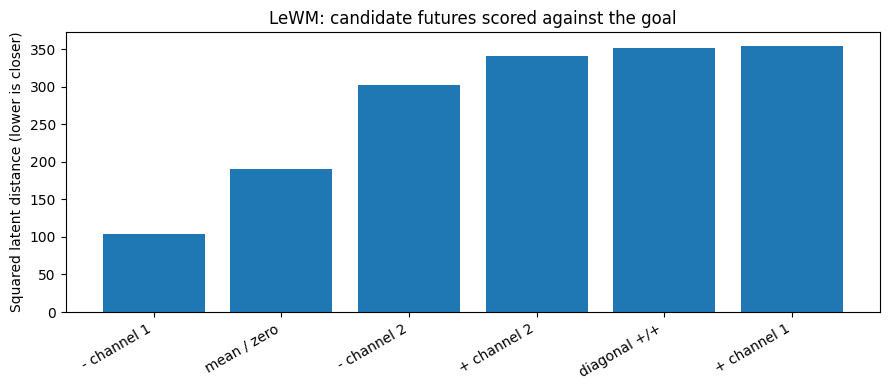

Lowest-distance candidate in this illustrative set:
- channel 1


In [8]:
#@title Latent goal-distance scores
final_pred = all_rollouts[:, -1, :]        # (S, D)
goal_vec = goal_emb[0]                     # (D,)

# Same basic cost used by the official LeWM criterion:
# summed per-dimension squared error at the final predicted latent state.
scores = ((final_pred - goal_vec) ** 2).sum(dim=-1)

scores_np = scores.detach().cpu().numpy()

result_df = pd.DataFrame({
    "candidate": candidate_names,
    "latent goal distance ↓": scores_np,
}).sort_values(
    "latent goal distance ↓",
    ascending=True,
).reset_index(drop=True)

display(result_df)

plt.figure(figsize=(9, 4))
plt.bar(
    result_df["candidate"],
    result_df["latent goal distance ↓"],
)
plt.ylabel("Squared latent distance (lower is closer)")
plt.xticks(rotation=30, ha="right")
plt.title("LeWM: candidate futures scored against the goal")
plt.tight_layout()
plt.show()

print("Lowest-distance candidate in this illustrative set:")
print(result_df.iloc[0]["candidate"])

## 9. Visualize the imagined futures in 2-D

The model actually operates in **192 dimensions**, so we cannot directly draw its latent trajectories.

For visualization only, PCA projects the embeddings to two dimensions.

Do **not** interpret the PCA axes semantically. The useful part is the relative geometry:

- all candidates start from the same current latent state;
- different actions produce diverging imagined futures;
- the goal appears as another point in the same learned representation space.

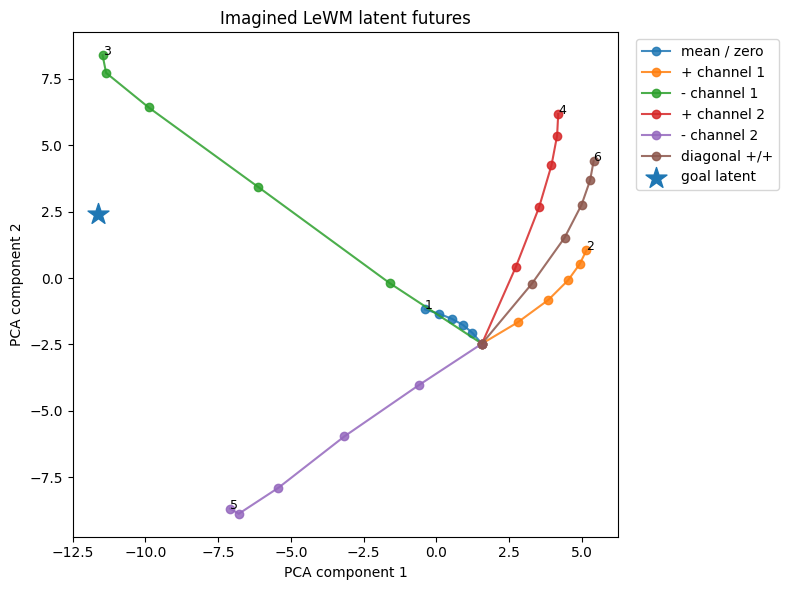

Explained variance by the two PCA dimensions: [0.432 0.289]


In [9]:
#@title PCA visualization of latent rollouts
# Last real context state + K predicted states.
traj = all_rollouts[:, HISTORY - 1:, :].detach().cpu()
goal_cpu = goal_emb.detach().cpu()  # (1, D)

S, L, D = traj.shape

X = torch.cat([
    traj.reshape(S * L, D),
    goal_cpu,
], dim=0).numpy()

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

traj2 = X2[:S * L].reshape(S, L, 2)
goal2 = X2[-1]

plt.figure(figsize=(8, 6))

for i, name in enumerate(candidate_names):
    plt.plot(
        traj2[i, :, 0],
        traj2[i, :, 1],
        marker="o",
        label=name,
        alpha=0.85,
    )
    plt.text(
        traj2[i, -1, 0],
        traj2[i, -1, 1],
        str(i + 1),
        fontsize=9,
    )

plt.scatter(
    [goal2[0]],
    [goal2[1]],
    marker="*",
    s=250,
    label="goal latent",
)

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Imagined LeWM latent futures")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(
    "Explained variance by the two PCA dimensions:",
    np.round(pca.explained_variance_ratio_, 3),
)

## 10. Final takeaway

### What this notebook demonstrated

We performed a real forward pass through the pretrained LeWM PushT model:

\[
\boxed{
\text{observation}
\rightarrow
\text{latent state}
\rightarrow
\text{action-conditioned latent rollout}
\rightarrow
\text{goal-distance score}
}
\]

### Why this matters

A world model can support planning **without decoding future pixels**.

We can imagine possible action sequences in latent space, score their predicted consequences, execute an action, observe the world again, and repeat:

```text
observe → encode → imagine → score → act → observe again
```

### Limitation of this 10-minute demo

The official PushT evaluation standardizes actions using statistics from the training data.  
To avoid downloading the full dataset, this notebook deliberately uses small illustrative candidate vectors in model-normalized space.

Therefore, the notebook demonstrates **real LeWM inference and latent-planning mechanics**, but it is not intended to reproduce the paper's exact PushT success rate or complete MPC evaluation protocol.

---

### References

- LeWM repository: https://github.com/lucas-maes/le-wm
- LeWM project page: https://le-wm.github.io/
- Pretrained PushT checkpoint: https://huggingface.co/quentinll/lewm-pusht